In [1]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

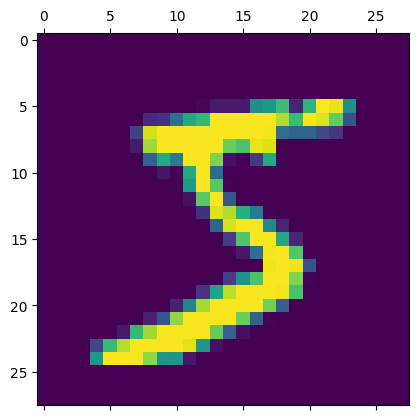

In [15]:
plt.matshow(X_train[0])

In [4]:
X_train = X_train/255
X_test = X_test/255
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [17]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape = (784,), activation='sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5


/Users/anondeesaha/Programming/soc_2026/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 247us/step - accuracy: 0.8796 - loss: 0.4637
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 252us/step - accuracy: 0.9151 - loss: 0.3034
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step - accuracy: 0.9209 - loss: 0.2831
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step - accuracy: 0.9232 - loss: 0.2731
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step - accuracy: 0.9261 - loss: 0.2665


In [18]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step - accuracy: 0.9263 - loss: 0.2635


[0.2634727358818054, 0.9262999892234802]

In [19]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 183us/step


array([2.3797674e-02, 4.9337478e-07, 5.8122043e-02, 9.5954269e-01,
       2.3954920e-03, 1.1474202e-01, 1.7395081e-06, 9.9981886e-01,
       7.9698995e-02, 6.9830930e-01], dtype=float32)

In [20]:
np.argmax(y_predicted[0])

np.int64(7)

Text(95.72222222222221, 0.5, 'Truth')

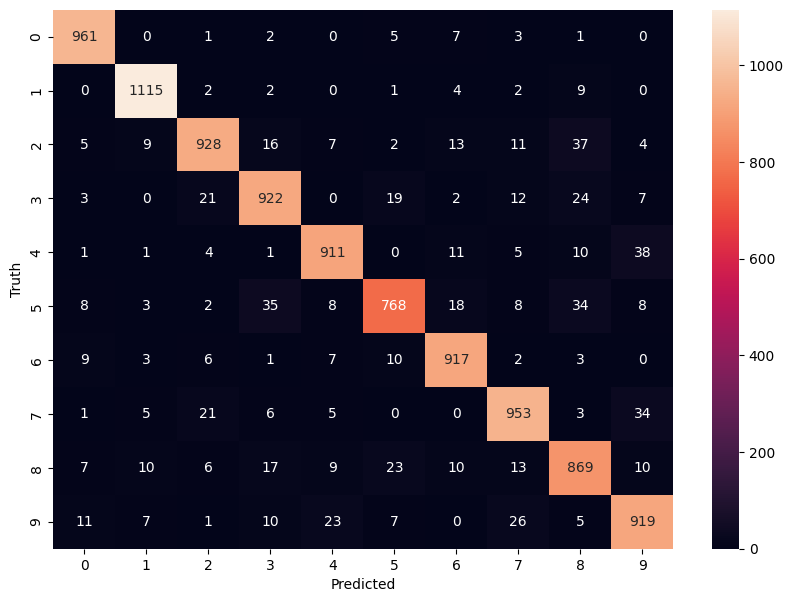

In [23]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)

import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm,annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [8]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, input_shape = (784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 496us/step - accuracy: 0.9218 - loss: 0.2735
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 482us/step - accuracy: 0.9632 - loss: 0.1256
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 488us/step - accuracy: 0.9742 - loss: 0.0863
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 492us/step - accuracy: 0.9801 - loss: 0.0661
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 470us/step - accuracy: 0.9839 - loss: 0.0522


In [27]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step - accuracy: 0.9759 - loss: 0.0824


[0.0824427455663681, 0.9758999943733215]

Activation:
step, sigmoid, relu, leaky relu, tanh

Loss:
mean absolute error 
mean squared error
log loss or binary cross entropy : -1/n * sum [yi*log(yhati)  + (1-yi)*log(1-yhati)]

In [40]:
y = np.array([1,1,0,0,1]) #predicted
yhat = np.array([0.30, 0.7, 1, 0, 0.5]) #truth

In [41]:
def mae(y,yhat) :
    total_err=0
    for yt, yp in zip(y, yhat):
        total_err+= abs(yt-yp)
    total_err/= len(y)
    print('error is', total_err)

In [42]:
mae(y, yhat)

error is 0.5


In [43]:
np.mean(np.abs(y-yhat))

np.float64(0.5)

In [44]:
epsilon = 1e-15
y_new = [max(i,epsilon) for i in y]
y_new

[np.int64(1), np.int64(1), 1e-15, 1e-15, np.int64(1)]

In [45]:
y_new = [min(i,(1-epsilon)) for i in y_new]
y_new

[0.999999999999999, 0.999999999999999, 1e-15, 1e-15, 0.999999999999999]

In [46]:
y_new=np.array(y_new)

In [3]:
def log_loss(y_true, y_predicted):
    y_predicted_new = [max(i,epsilon) for i in y_predicted]
    y_predicted_new = [min(i,1-epsilon) for i in y_predicted_new]
    y_predicted_new = np.array(y_predicted_new)
    return -np.mean(y_true*np.log(y_predicted_new)+(1-y_true)*np.log(1-y_predicted_new))

In [51]:
log_loss(yhat, y)

np.float64(17.2696280766844)

In [50]:
-np.mean(yhat*np.log(y_new)+(1-yhat)*np.log(1-y_new))

np.float64(17.2696280766844)

Gradient descent

In [4]:
df = pd.read_csv('insurance_data.csv')
df['age'] = df['age']/100
df.head()

,age,affordibility,bought_insurance
0,0.22,1,0
1,0.25,0,0
2,0.47,1,1
3,0.52,0,0
4,0.46,1,1


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['age', 'affordibility']], df['bought_insurance'], test_size=0.2, random_state=25)

In [6]:
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(2,), activation='sigmoid', kernel_initializer='ones', bias_initializer='zeros')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train, y_train, epochs=10)

Epoch 1/10


/Users/anondeesaha/Programming/soc_2026/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5000 - loss: 0.7113
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.7110
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7106
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.7102
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7098
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7094
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7091
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7087
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.7083
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.7079


In [7]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.7282


[0.7282423973083496, 0.5]

In [8]:
coef, intercept = model.get_weights()
coef, intercept

(array([[0.99001  ],
        [0.9900079]], dtype=float32),
 array([-0.00999467], dtype=float32))

In [ ]:
def sigmoid_numpy(X):
    return 1/(1+np.exp(-X))

In [9]:
def gradient_descent(age, affordibility, y_true, epochs, loss_threshold):
    w1 = w2 = 1
    bias = 0
    rate = 0.5
    n = len(age)

    for i in range(epochs):
        weighted_sum = age*w1 + affordibility*w2 + bias
        y = sigmoid_numpy(weighted_sum)
        loss = log_loss(y_true, y)

        dw1 = (1/n)*np.dot(np.transpose(age), (y-y_true))
        dw2 = (1/n)*np.dot(np.transpose(affordibility), (y-y_true))
        dbias = np.mean(y-y_true)

        w1 = w1 - rate*dw1
        w2 = w2 - rate*dw2
        bias = bias - rate*dbias

        if loss <=loss_threshold :
            break

    return w1, w2, bias

Stochastic gradient descent - calculate weights after each randomly picked sample - good for huge data sets
Batch gradient descent - use all training examples for one forward pass and then adjust weights
Mini batech gradient descent - use a batch of (randomly picked) samples for forward pass then adjust weights

In [ ]:
import random
def stochastic_gradient_descent(X, y_true, epochs, learning_rate=0.01):
    num_of_features = X.shape[1]
    w = np.ones(shape=(num_of_features))
    b = 0
    total_samples = X.shape[0]

    cost_list = []
    epoch_list = []

    for i in range(epochs):
        random_index = random.randint(0, total_samples-1)
        sample_x = X[random_index]
        sample_y = y_true[random_index]
        y_predicted = np.dot(w, sample_x.T)+b

        w_grad = (2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
        b_grad = (2/total_samples)*(sample_y-y_predicted)

        w = w - learning_rate*w_grad
        b = b - learning_rate*b_grad

        cost = np.square(sample_y-y_predicted)

        if i%100==0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w, b, cost_list, epoch_list

Preprocessing: scaling images:
X_train.shape - (50000, 32, 32, 3)

X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

y_train_categorical = keras.utils.to_categorical(
    y_train, num_classes=10, dtype='float32'
)
y_test_categorical = keras.utils.to_categorical(
    y_test, num_classes=10, dtype='float32'
)

y_train[0:5] - array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

y_train_categorical[0:5] - array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

for loss use categorical_crossenctropy instead of sparse catergorical cross entropy as we did one hot encdoding

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5340,5032-USPKF,Female,0,No,No,38,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),84.10,3187.65,No
3895,4979-HPRFL,Male,0,Yes,Yes,56,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.15,1402.25,No
710,1029-QFBEN,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,Yes
3995,0618-XWMSS,Male,0,No,Yes,28,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.90,2068.55,Yes
1803,2773-MADBQ,Female,0,No,No,36,No,No phone service,DSL,Yes,...,Yes,Yes,No,Yes,Two year,Yes,Mailed check,53.10,1901.25,No


In [3]:
df.drop('customerID', axis='columns', inplace=True)
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df[pd.to_numeric(df.TotalCharges, errors='coerce').isnull()].shape

(11, 20)

In [8]:
df1 = df[df.TotalCharges != ' '] 
df1.shape

(7032, 20)

In [10]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

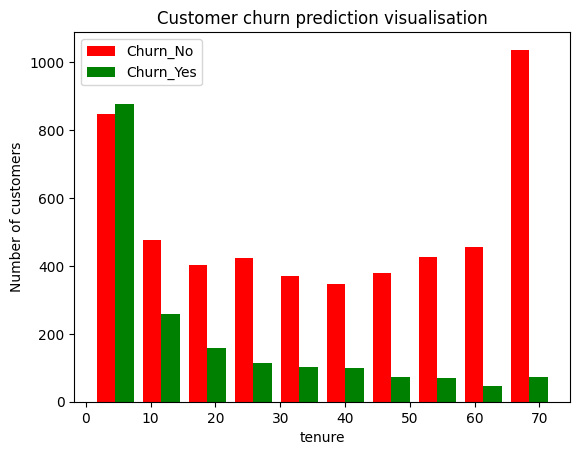

In [14]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number of customers")
plt.title("Customer churn prediction visualisation")

plt.hist([tenure_churn_no, tenure_churn_yes], color=['red', 'green'], label=['Churn_No', 'Churn_Yes'])
plt.legend()

In [16]:
def print_unique_col(df):
    for column in df:
        if df[column].dtypes == 'object':
            print(f'{column}:{df[column].unique()}')

In [ ]:
print_unique_col(df1)

In [23]:
df1.replace('No internet service', 'No', inplace=True)
df1.replace('No phone service', 'No', inplace=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [32]:
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
df1[yes_no_cols] = df1[yes_no_cols].replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

In [37]:
df1['gender'] = df1['gender'].replace({'Female':1, 'Male':0})

In [39]:
df2 = pd.get_dummies(data=df1, columns=['InternetService', 'Contract', 'PaymentMethod'])
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [64]:
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])
obj_cols = df2.select_dtypes(include='object').columns
df2[obj_cols] = df2[obj_cols].apply(pd.to_numeric, errors='coerce')

In [65]:
df2.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3385,0,0,0,0,0.154930,1,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False
3155,0,0,0,1,0.394366,1,0,0,0,0,...,False,False,True,False,True,False,False,False,False,True
3921,1,0,1,0,0.323944,1,1,1,1,1,...,True,False,False,True,False,False,False,False,False,True
5432,1,0,0,0,0.014085,1,0,0,0,1,...,True,False,False,True,False,False,False,False,True,False
6265,1,0,0,0,0.014085,1,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True


In [66]:
X = df2.drop('Churn', axis='columns')
y = df2['Churn']

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [72]:
len(X_train.columns)

26

In [73]:
model = keras.Sequential([
    keras.layers.Dense(26, input_shape=(26,), activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


model.fit(X_train, y_train, epochs=10)

Epoch 1/10


/Users/anondeesaha/Programming/soc_2026/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.7415 - loss: 0.5193
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.7900 - loss: 0.4375
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step - accuracy: 0.7956 - loss: 0.4249
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.7986 - loss: 0.4199
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - accuracy: 0.8020 - loss: 0.4167
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.8027 - loss: 0.4158
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - accuracy: 0.8027 - loss: 0.4140
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step - accuracy: 0.8037 - loss: 0.4131
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step - accuracy: 0.8082 - loss: 0.4122
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - accuracy: 0.8084 - loss: 0.4110


True Positive, True Negative, False Positive, False Negative
Accuracy - how many you got right - TP+TN/TP+TN+FP+FN
Precision - out of positive predictions how many are right - TP/TP+FP
Recall - out of all dog truth how many are right
Precison and recall are all about one particular class
F1 - harmonic mean of precision and recall

In [77]:
from sklearn.metrics import confusion_matrix , classification_report

In [79]:
def ANN(X_train, y_train, X_test, y_test, loss, weights):
    model = keras.Sequential([
        keras.layers.Dense(26, input_dim=26, activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    
    if weights == -1:
        model.fit(X_train, y_train, epochs=10)
    else:
        model.fit(X_train, y_train, epochs=10, class_weight = weights)
    
    print(model.evaluate(X_test, y_test))
    
    y_preds = model.predict(X_test)
    y_preds = np.round(y_preds)
    
    print("Classification Report: \n", classification_report(y_test, y_preds))
    
    return y_preds

In [80]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/10


/Users/anondeesaha/Programming/soc_2026/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - accuracy: 0.7616 - loss: 0.5033
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step - accuracy: 0.7925 - loss: 0.4284
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step - accuracy: 0.7964 - loss: 0.4205
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - accuracy: 0.7979 - loss: 0.4164
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.8050 - loss: 0.4142
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.8037 - loss: 0.4113
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - accuracy: 0.8048 - loss: 0.4093
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step - accuracy: 0.8062 - loss: 0.4079
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step - accuracy: 0.8069 - loss: 0.4057
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 309us/step - accuracy: 0.8094 - loss: 0.4047
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - accuracy: 0.8053 - loss: 0.4264
[0.42635512351989746, 0.8052594065666199]
44/44 ━━━━━━━

Mitigating skewness in data
Method 1: undersampling: here class 0 has almost 5 times more samples than class 1 hence we will undersample class 0
# Undersample 0-class and concat the DataFrames of both class
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

Method 2: oversampling: 
# Oversample 1-class and concat the DataFrames of both classes
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

Method 3: SMOTE: uses k nearest algorithm

In [84]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

Churn
0    5163
1    5163
Name: count, dtype: int64

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/10


/Users/anondeesaha/Programming/soc_2026/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.7222 - loss: 0.5496
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step - accuracy: 0.7748 - loss: 0.4698
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - accuracy: 0.7824 - loss: 0.4609
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.7860 - loss: 0.4560
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - accuracy: 0.7884 - loss: 0.4509
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.7900 - loss: 0.4483
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.7962 - loss: 0.4432
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step - accuracy: 0.7943 - loss: 0.4393
Epoch 9/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step - accuracy: 0.7959 - loss: 0.4349
Epoch 10/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step - accuracy: 0.7998 - loss: 0.4319
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - accuracy: 0.7851 - loss: 0.4487
[0.4487302005290985, 0.7850919365882874]
65/65 ━━━━━━━━

Image classification
from keras import datasets, models, layers
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()

y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cnn.fit(X_train, y_train, epochs=10)

Valid convolution: m x n matrix with f x f matrix - results in a (m-f+1) x (n-f+1)
But the pixels on the edge barely play a role in feature detection as they are included in a convolution operation only once
Hence the need for convolution padding - by default it is valid (not applied)

strides - step size for moving the feature window (x,y) - by default it is (1,1)

Data augmentation
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Transfer Learning - research problem in ML where you use a pre-trained model to train a new different but related model. 
Freeze all the layers except the last one
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

num_of_flowers = 5

model = tf.keras.Sequential([
  pretrained_model_without_top_layer,
  tf.keras.layers.Dense(num_of_flowers)
])

model.summary()

model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)